Batches: 100%|██████████| 5/5 [00:01<00:00,  4.20it/s]



=== Issue Group 0 ===
 Paper jam fix
 Paper jam fix
Scanner repair
 Paper jam fix
 Paper jam fix

=== Issue Group 1 ===
Auto-feeder service
Auto-feeder service
Auto-feeder service
Auto-feeder service
Auto-feeder service

=== Issue Group 2 ===
Sensor replacement
 Fuser replacement
 Toner replacement
Sensor replacement
 Cooling fan check

=== Issue Group 3 ===
   Network reset
   Network reset
 Firmware update
   Network reset
Diagnostic check

=== Issue Group 4 ===
Belt tension adjust
     Tray alignment
Belt tension adjust
     Tray alignment
     Tray alignment

=== Issue Group 5 ===
Waste toner cleared
  Ink nozzle unclog
Waste toner cleared
  Ink nozzle unclog
  Ink nozzle unclog


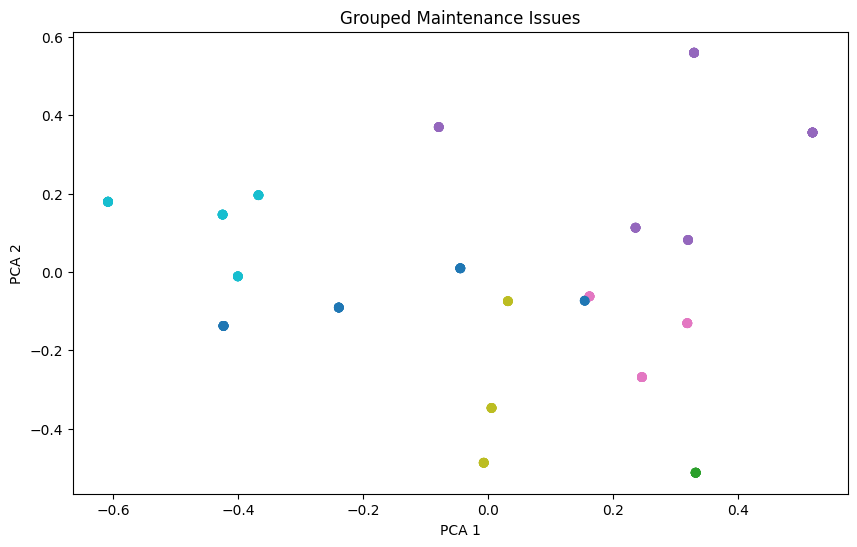

In [4]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load maintenance records
df = pd.read_csv("../../Data/train/maintenance_records.csv")
df['description'] = df['description'].fillna('').astype(str)

# Step 1: Embed descriptions using a pretrained transformer
model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight and fast
embeddings = model.encode(df['description'].tolist(), show_progress_bar=True)

# Step 2: Cluster embedded descriptions
num_clusters = 6  # You can tweak this to find best grouping
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['issue_group'] = kmeans.fit_predict(embeddings)

# Step 3: Review samples from each group
for i in range(num_clusters):
    print(f"\n=== Issue Group {i} ===")
    print(df[df['issue_group'] == i]['description'].sample(5).to_string(index=False))

# Optional: Visualize the issue groups
reduced = PCA(n_components=2).fit_transform(embeddings)
plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=df['issue_group'], cmap='tab10')
plt.title('Grouped Maintenance Issues')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()
# from sentence_transformers import SentenceTransformer
# import transformers
# print(transformers.__version__)
# model = SentenceTransformer('all-MiniLM-L6-v2')
# embedding = model.encode("Test sentence for embedding.")
# print(embedding[:5])  # print first 5 values of the vector


In [6]:
# import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Load labeled dataset
df = pd.read_csv("maintenance_issues_labeled_updated.csv")  # Make sure this has 'description' and 'issue_type'

# Step 2: Preprocess descriptions
df['description'] = df['description'].fillna('').astype(str)

# Step 3: Encode text descriptions
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['description'].tolist(), show_progress_bar=True)

# Step 4: Features and labels
X = embeddings
y = df['issue_type']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = knn.predict(X_test)

# ✅ Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"🔍 Model Accuracy: {accuracy:.2%}\n")

# ✅ Classification Report
print("📊 Classification Report:\n", classification_report(y_test, y_pred))


Batches: 100%|██████████| 5/5 [00:00<00:00,  7.91it/s]

🔍 Model Accuracy: 100.00%

📊 Classification Report:
                      precision    recall  f1-score   support

     Firmware Issue       1.00      1.00      1.00         4
          Paper Jam       1.00      1.00      1.00         8
       Roller Issue       1.00      1.00      1.00         6
Routine Maintenance       1.00      1.00      1.00         5
       Sensor Issue       1.00      1.00      1.00         6

           accuracy                           1.00        29
          macro avg       1.00      1.00      1.00        29
       weighted avg       1.00      1.00      1.00        29

